In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse, very_small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_sROM, target_function, get_predictions, get_improvement
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [3]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"
NN = np.load(pth+"/NN2.npy")
dN_ROM = np.load(pth+"/dN_ROM.npy")
dN_sig_sROM = np.load(pth+"/dN_sig_sROM.npy")
dN_sig_dsROM = np.load(pth+"/dN_sig_dsROM.npy")
sig = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
sig = np.array([0.064, 0.032, 0.016, 0.008, 0.004, 0.002])

In [4]:
plateauS = dN_sig_sROM[-1]
plateauDS = dN_sig_dsROM[-1]
print(plateauS)
print(plateauDS)
print(plateauS/np.array(sig)**.5)
print(plateauDS/np.array(sig)**.5)
print(sig)

[0.09589696 0.09167985 0.08311504 0.06694561 0.0454554  0.03184429]
[0.07401869 0.04406487 0.02417429 0.01648463 0.02032431 0.01827922]
[0.37906601 0.51250594 0.65708208 0.74847468 0.71871296 0.71205989]
[0.29258455 0.24633011 0.19111457 0.18430371 0.32135564 0.40873577]
[0.064 0.032 0.016 0.008 0.004 0.002]


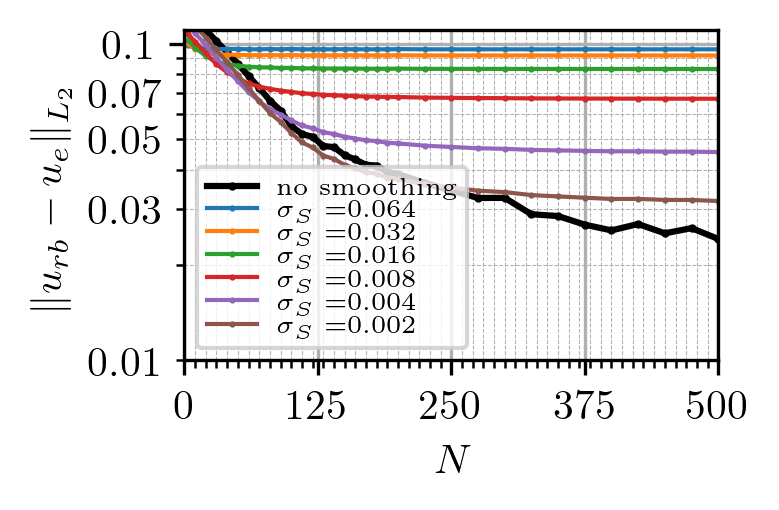

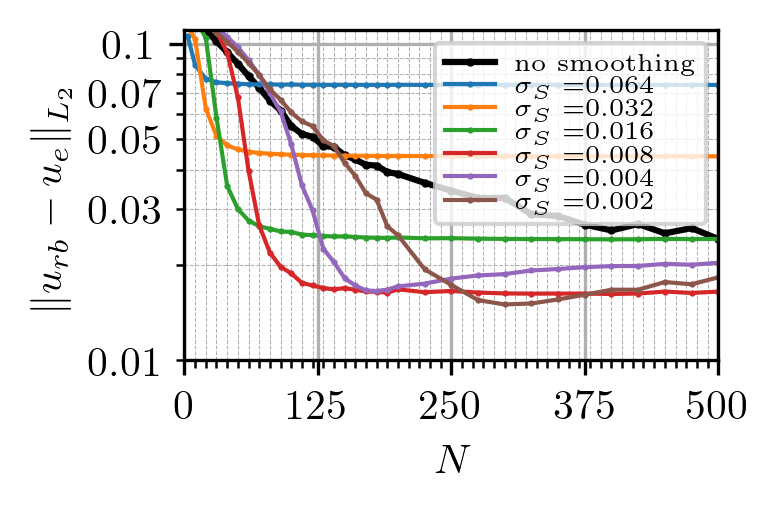

In [5]:
fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.-", ms=2, label=r"no smoothing")
for j in range(6):
    plt.plot(NN, dN_sig_sROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.01, 0.11)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 125, 250, 375, 500], minor=False)
ax.set_yticks(np.linspace(0.01, 0.1, 10, endpoint=True), minor=True)
ax.set_yticks([0.1], minor=False)
ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1"], minor=False)

plt.show()

fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.-", ms=2, label=r"no smoothing")
for j in range(6):
    plt.plot(NN, dN_sig_dsROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.01, 0.11)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 125, 250, 375, 500], minor=False)
ax.set_yticks(np.linspace(0.01, 0.1, 10, endpoint=True), minor=True)
ax.set_yticks([0.1], minor=False)
ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1"], minor=False)

plt.show()